# SASHIMI-SI: legacy API and ITAMAE migration demo

This lightweight notebook compares the established `sashimi_si` API with the opt-in ITAMAE façade. It checks the full 27-array legacy contract, constructs named weighted catalogs, and compares the SIDM subhalo mass function and accumulated satellite number.

## Physics status

Both migration labels use the corrected upstream physics merged in `e17d366`: the growth-factor derivative has no spurious $h^{-2}$, the gravothermal derivative uses the published $\tau^7$ coefficient, Eq. (3.3) is normalized by the running CDM history, and the diagnostic and evolution paths share the analytic effective cross section.

`physics_mode="legacy"` means the current corrected public `sashimi_si` model. It does **not** restore the known-bad pre-fix equations. For SASHIMI-SI, `legacy` and `consistent` therefore have identical physical results; the difference is the explicit opt-in API and the recorded metadata label.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Markdown, display

from sashimi_si import subhalo_properties as LegacySubhaloProperties
from sashimi_si_itamae import create_itamae_model

plt.rcParams.update({"figure.figsize": (11, 4), "font.size": 11})

## Small reproducible calculation

The grid is intentionally small enough for documentation and CI-style execution. The SIDM parameters match the example in `sample.ipynb`.

In [2]:
MODEL_PARAMETERS = {"sigma0_m": 147.1, "w": 24.33}
RUN_PARAMETERS = {
    "M0": 1.0e10,
    "redshift": 0.0,
    "dz": 0.5,
    "zmax": 1.0,
    "N_ma": 4,
    "sigmalogc": 0.128,
    "N_herm": 2,
    "logmamin": 5.0,
    "logmamax": 7.0,
    "N_hermNa": 2,
    "Na_model": 3,
    "ct_th": 0.0,
    "method": "pert2_shanks",
}

In [3]:
with warnings.catch_warnings(record=True) as captured_warnings:
    warnings.simplefilter("always", RuntimeWarning)

    public_legacy_model = LegacySubhaloProperties(**MODEL_PARAMETERS)
    public_legacy_tuple = public_legacy_model.subhalo_properties_calc(
        **RUN_PARAMETERS
    )

    migrated_legacy_model = create_itamae_model(
        physics_mode="legacy", **MODEL_PARAMETERS
    )
    migrated_legacy_tuple = migrated_legacy_model.subhalo_properties_calc(
        **RUN_PARAMETERS
    )
    migrated_legacy_catalogs = migrated_legacy_model.subhalo_catalogs_calc(
        **RUN_PARAMETERS
    )

    consistent_model = create_itamae_model(
        physics_mode="consistent", **MODEL_PARAMETERS
    )
    consistent_catalogs = consistent_model.subhalo_catalogs_calc(
        **RUN_PARAMETERS
    )

Calculating subhalo properties:   0%|          | 0/2 [00:00<?, ?it/s]

Calculating subhalo properties: 100%|██████████| 2/2 [00:00<00:00, 366.46it/s]

Calculating subhalo properties:   0%|          | 0/2 [00:00<?, ?it/s]

Calculating subhalo properties: 100%|██████████| 2/2 [00:00<00:00, 390.64it/s]

Calculating subhalo properties:   0%|          | 0/2 [00:00<?, ?it/s]

Calculating subhalo properties: 100%|██████████| 2/2 [00:00<00:00, 397.08it/s]

Calculating subhalo properties:   0%|          | 0/2 [00:00<?, ?it/s]

Calculating subhalo properties: 100%|██████████| 2/2 [00:00<00:00, 398.68it/s]

In [4]:
assert len(public_legacy_tuple) == len(migrated_legacy_tuple) == 27
for index, (public_value, migrated_value) in enumerate(
    zip(public_legacy_tuple, migrated_legacy_tuple, strict=True)
):
    if index in {25, 26}:
        np.testing.assert_array_equal(migrated_value, public_value)
    else:
        np.testing.assert_allclose(
            migrated_value,
            public_value,
            rtol=3.0e-5 if index == 21 else 5.0e-12,
            atol=2.0e-4 if index == 21 else 1.0e-300,
        )

api_rows = [
    ("Public legacy", "sashimi_si", "27-array tuple", "current corrected physics"),
    ("Migrated legacy", "sashimi_si_itamae", "tuple or named catalogs", "metadata: legacy"),
    ("Migrated consistent", "sashimi_si_itamae", "tuple or named catalogs", "metadata: consistent"),
]
table = [
    "| Interface | Import | Result | SI physics / label |",
    "|---|---|---|---|",
    *["| " + " | ".join(row) + " |" for row in api_rows],
]
display(Markdown("\n".join(table)))

preview_columns = ("m200_acc", "z_acc", "m_bound", "r_s_sidm", "collapse_time_ratio")
preview_rows = []
for index in range(min(6, len(migrated_legacy_catalogs["sidm"]))):
    preview_rows.append(
        tuple(
            [f"{float(migrated_legacy_catalogs['sidm'].columns[name][index]):.5g}" for name in preview_columns]
            + [f"{migrated_legacy_catalogs['sidm'].weight_final[index]:.5g}"]
        )
    )
preview = [
    "\nFirst rows of the migrated SIDM weighted catalogue:",
    "",
    "| " + " | ".join((*preview_columns, "weight_final")) + " |",
    "|" + "---:|" * (len(preview_columns) + 1),
    *["| " + " | ".join(row) + " |" for row in preview_rows],
]
display(Markdown("\n".join(preview)))

| Interface | Import | Result | SI physics / label |
|---|---|---|---|
| Public legacy | sashimi_si | 27-array tuple | current corrected physics |
| Migrated legacy | sashimi_si_itamae | tuple or named catalogs | metadata: legacy |
| Migrated consistent | sashimi_si_itamae | tuple or named catalogs | metadata: consistent |


First rows of the migrated SIDM weighted catalogue:

| m200_acc | z_acc | m_bound | r_s_sidm | collapse_time_ratio | weight_final |
|---:|---:|---:|---:|---:|---:|
| 87947 | 0.5 | 35744 | 2.9601e-05 | 0.10086 | 52.101 |
| 4.0567e+05 | 0.5 | 1.6163e+05 | 5.0575e-05 | 0.14304 | 13.948 |
| 1.8702e+06 | 0.5 | 7.3031e+05 | 8.6888e-05 | 0.19708 | 3.855 |
| 8.616e+06 | 0.5 | 3.2971e+06 | 0.00015049 | 0.25686 | 1.1151 |
| 87947 | 0.5 | 35744 | 1.4897e-05 | 0.52903 | 52.101 |
| 4.0567e+05 | 0.5 | 1.6163e+05 | 2.437e-05 | 0.74146 | 13.948 |

## Population observables

For fixed logarithmic mass bins, the mass function is $dN/d\ln m$. The accumulated satellite number is the expected weighted count $N(>m_{\rm threshold})$. The structured catalog's `weight_final` already multiplies the base, concentration, and survival factors.

In [5]:
def mass_function(mass, weight, bin_edges):
    log_edges = np.log(np.asarray(bin_edges, dtype=float))
    counts, _ = np.histogram(
        np.log(np.asarray(mass, dtype=float)),
        bins=log_edges,
        weights=np.asarray(weight, dtype=float),
    )
    centers = np.sqrt(bin_edges[:-1] * bin_edges[1:])
    return centers, counts / np.diff(log_edges)


def accumulated_number(mass, weight, thresholds):
    mass = np.asarray(mass, dtype=float)
    weight = np.asarray(weight, dtype=float)
    return np.asarray(
        [np.sum(weight[mass >= threshold]) for threshold in thresholds]
    )


public_mass = np.asarray(public_legacy_tuple[11])
public_sidm_weight = np.asarray(public_legacy_tuple[24])
legacy_sidm_catalog = migrated_legacy_catalogs["sidm"]
consistent_sidm_catalog = consistent_catalogs["sidm"]

bin_edges = np.geomspace(1.0e4, 1.0e7, 13)
threshold_grid = np.geomspace(1.0e4, 1.0e7, 80)

series = {
    "public legacy": (public_mass, public_sidm_weight),
    "migration: legacy": (
        legacy_sidm_catalog.columns["m_bound"],
        legacy_sidm_catalog.weight_final,
    ),
    "migration: consistent": (
        consistent_sidm_catalog.columns["m_bound"],
        consistent_sidm_catalog.weight_final,
    ),
}

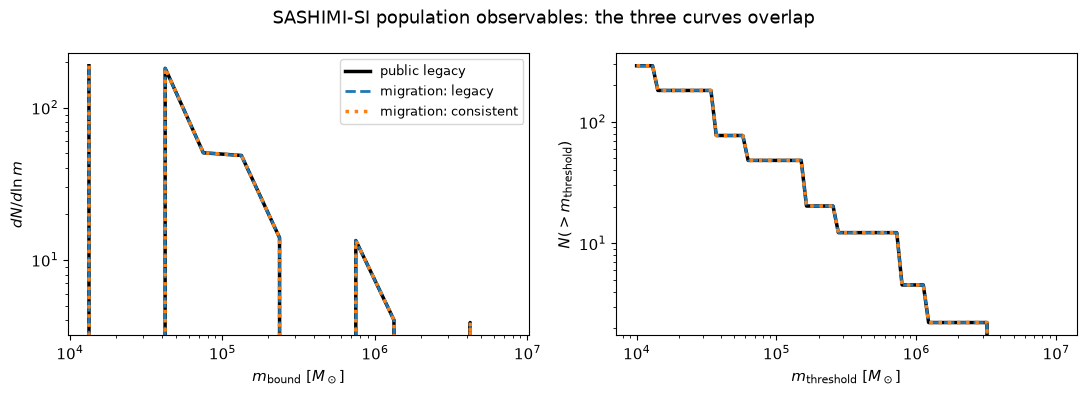

In [6]:
fig, axes = plt.subplots(1, 2)
styles = [
    {"color": "black", "linestyle": "-", "linewidth": 2.5},
    {"color": "tab:blue", "linestyle": "--", "linewidth": 2.0},
    {"color": "tab:orange", "linestyle": ":", "linewidth": 2.5},
]

for (label, (mass, weight)), style in zip(series.items(), styles, strict=True):
    centers, dndlnm = mass_function(mass, weight, bin_edges)
    axes[0].plot(centers, dndlnm, label=label, **style)
    axes[1].plot(
        threshold_grid,
        accumulated_number(mass, weight, threshold_grid),
        label=label,
        **style,
    )

axes[0].set(xscale="log", yscale="log", xlabel=r"$m_{\rm bound}\ [M_\odot]$", ylabel=r"$dN/d\ln m$")
axes[1].set(xscale="log", yscale="log", xlabel=r"$m_{\rm threshold}\ [M_\odot]$", ylabel=r"$N(>m_{\rm threshold})$")
axes[0].legend(fontsize=9)
fig.suptitle("SASHIMI-SI population observables: the three curves overlap")
fig.tight_layout()
plt.show()

In [7]:
selected_thresholds = np.asarray([1.0e4, 1.0e5, 1.0e6])
counts = {
    label: accumulated_number(mass, weight, selected_thresholds)
    for label, (mass, weight) in series.items()
}

rows = []
for index, threshold in enumerate(selected_thresholds):
    rows.append(
        (
            f"{threshold:.0e}",
            f"{counts['public legacy'][index]:.8f}",
            f"{counts['migration: legacy'][index]:.8f}",
            f"{counts['migration: consistent'][index]:.8f}",
        )
    )

table = [
    "| Mass threshold [$M_\\odot$] | Public legacy | Migration legacy | Migration consistent |",
    "|---:|---:|---:|---:|",
    *["| " + " | ".join(row) + " |" for row in rows],
]
display(Markdown("\n".join(table)))

np.testing.assert_allclose(
    counts["migration: legacy"], counts["public legacy"], rtol=5.0e-12
)
np.testing.assert_allclose(
    counts["migration: consistent"], counts["migration: legacy"], rtol=5.0e-12
)
print("Numerical agreement checks passed.")

| Mass threshold [$M_\odot$] | Public legacy | Migration legacy | Migration consistent |
|---:|---:|---:|---:|
| 1e+04 | 289.76450661 | 289.76450661 | 289.76450661 |
| 1e+05 | 48.18546597 | 48.18546597 | 48.18546597 |
| 1e+06 | 4.54791225 | 4.54791225 | 4.54791225 |

Numerical agreement checks passed.


In [8]:
warning_messages = sorted({str(item.message) for item in captured_warnings})
warning_lines = [
    "### Known runtime warnings observed during the demonstration",
    "",
    *[f"- `{message}`" for message in warning_messages],
    "",
    "The effective-cross-section interpolation evaluates its direct expression before selecting the stable large-$a$ asymptotic branch. The true legacy Shanks implementation also evaluates zero-denominator intermediate expressions before applying its fallback. These warnings describe discarded intermediate arithmetic; the validated catalog arrays and weights used above are finite. They are not a `legacy`/`consistent` physics difference.",
    "",
    "Larger validation grids may additionally warn while evaluating a square root for an invalid trial SIDM profile or an EPS normalization outside its active accretion mask. Those nodes are subsequently masked or rejected, and the regression suite requires the surviving catalog to remain finite and physical.",
]
display(Markdown("\n".join(warning_lines)))

### Known runtime warnings observed during the demonstration

- `invalid value encountered in divide`
- `invalid value encountered in multiply`
- `overflow encountered in exp`

The effective-cross-section interpolation evaluates its direct expression before selecting the stable large-$a$ asymptotic branch. The true legacy Shanks implementation also evaluates zero-denominator intermediate expressions before applying its fallback. These warnings describe discarded intermediate arithmetic; the validated catalog arrays and weights used above are finite. They are not a `legacy`/`consistent` physics difference.

Larger validation grids may additionally warn while evaluating a square root for an invalid trial SIDM profile or an EPS normalization outside its active accretion mask. Those nodes are subsequently masked or rejected, and the regression suite requires the surviving catalog to remain finite and physical.

## Conclusion

- Existing users can keep importing `sashimi_si` and receiving the 27-array tuple.
- New workflows can opt into `sashimi_si_itamae` for named CDM-reference/SIDM catalogs, factorized weights, canonical units, and provenance metadata.
- For current corrected SASHIMI-SI physics, `physics_mode="legacy"` and `physics_mode="consistent"` intentionally produce the same population. The mode label is retained for a uniform cross-family API.